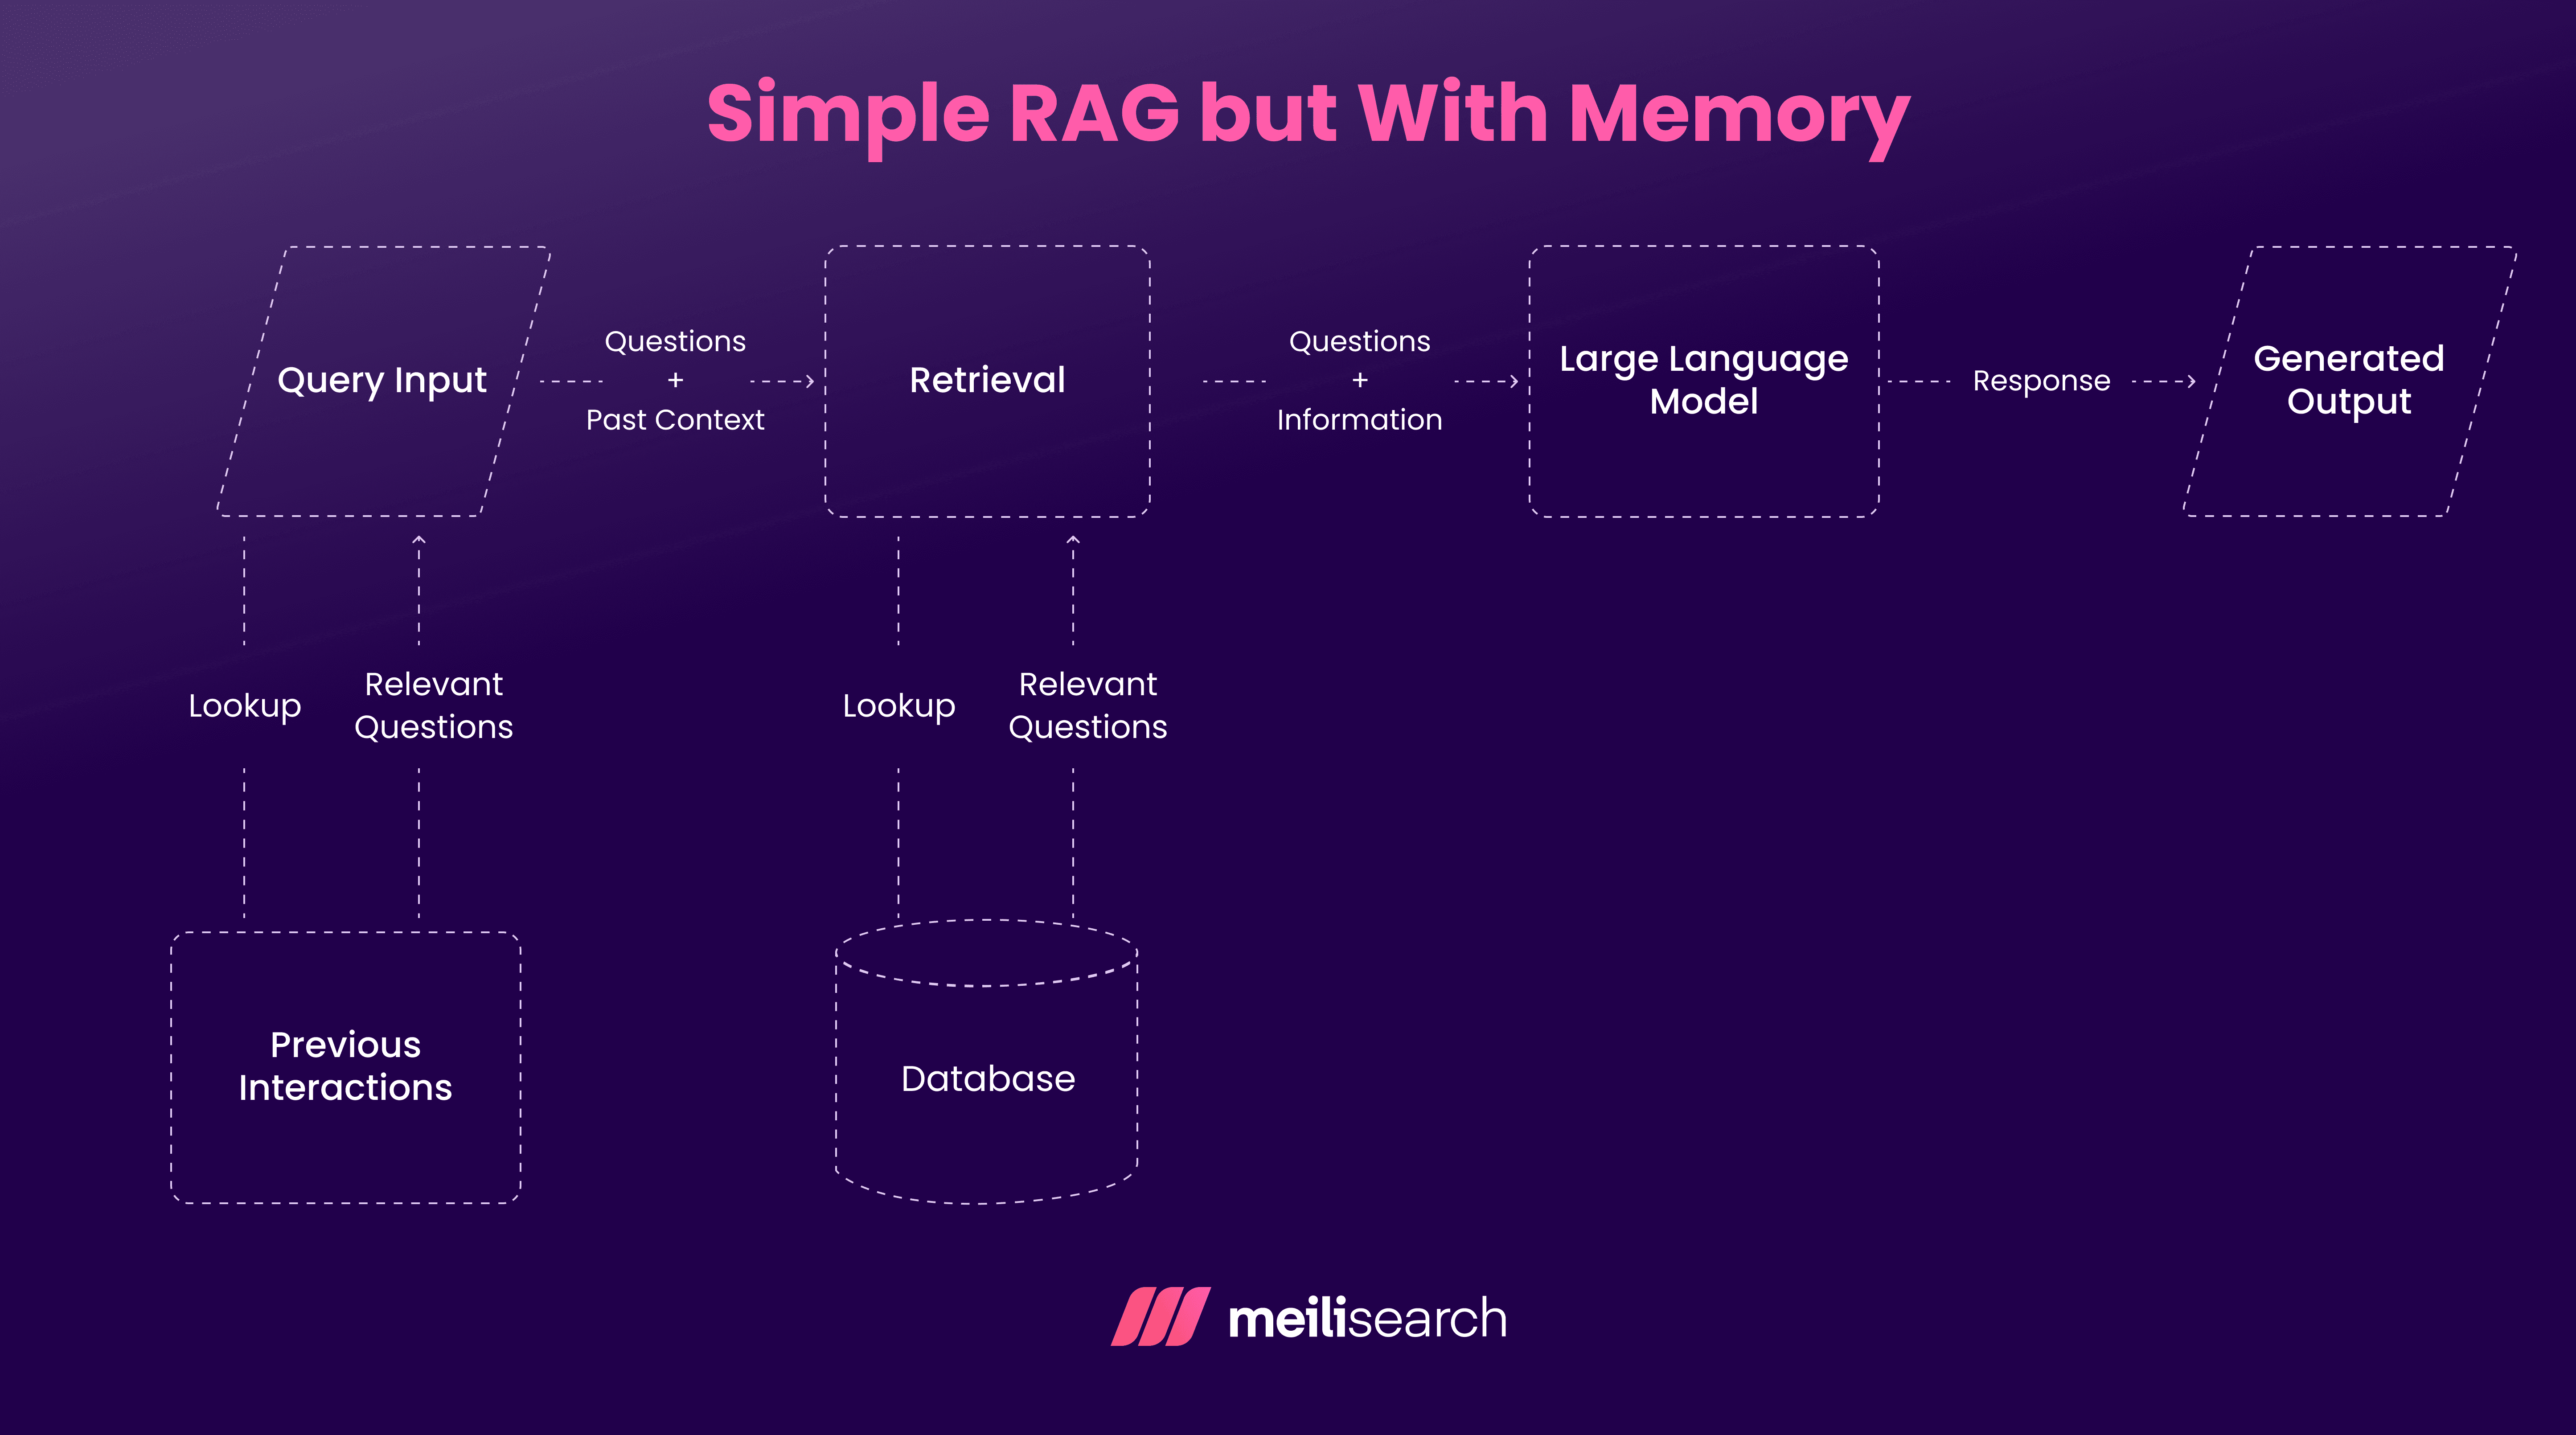

In [12]:
import subprocess
import time
import threading


# 1. Install required dependency zstd for Ollama installation
!apt-get install zstd -qq

# Install Ollama and the Python library
!curl -fsSL https://ollama.com/install.sh | sh
!pip install ollama -q
import ollama
# 2. Start Ollama server in the background
def run_ollama():
    subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

threading.Thread(target=run_ollama, daemon=True).start()
time.sleep(5)  # Give the server a moment to warm up

# 3. Pull a odel (Llama 3.2 is ~2GB)
print("Downloading model...")
ollama.pull('llama3.2')

# 4. Ask a simple question
print("\n--- Model Response ---")
response = ollama.chat(model='llama3.2', messages=[
    {'role': 'user', 'content': 'What is the most interesting fact about space?'}
])

print(response['message']['content'])

>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.

--- Model Response ---
There are countless fascinating facts about space, and it's hard to pick just one. However, here's a mind-blowing one:

**The Universe is Still Expanding, and the Rate of Expansion is Accelerating**

In 1929, Edwin Hubble discovered that the universe is expanding, with galaxies moving away from each other. This was a groundbreaking discovery that revolutionized our understanding of the cosmos.

But what's even more astonishing is that the rate of expansion is not constant. Instead, it's accelerating! In the 1990s, observa

In [2]:
# --- Simple RAG with Memory using SQLite ---
# Process Flow:
# 1. Store previous interactions in SQLite.
# 2. Store dataset (knowledge base) in SQLite.
# 3. Query input combines new question + past context.
# 4. Retrieval searches SQLite for relevant info.
# 5. LLM consumes both question + retrieved info.
# 6. Generated output is returned.

import sqlite3

# --- Setup SQLite ---
conn = sqlite3.connect("rag_memory.db")
cur = conn.cursor()

# Create tables
cur.execute("""
CREATE TABLE IF NOT EXISTS interactions (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    text TEXT
)
""")

cur.execute("""
CREATE TABLE IF NOT EXISTS dataset (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    key TEXT,
    value TEXT
)
""")
conn.commit()

# --- Insert sample data ---
# Previous interactions
cur.execute("INSERT INTO interactions (text) VALUES (?)", ("User previously asked about Alice's role.",))
cur.execute("INSERT INTO interactions (text) VALUES (?)", ("User previously asked about Project Apollo deadline.",))

# Dataset
cur.execute("INSERT INTO dataset (key, value) VALUES (?, ?)", ("Alice", "Alice works in Engineering and reports to the CTO."))
cur.execute("INSERT INTO dataset (key, value) VALUES (?, ?)", ("Apollo", "Project Apollo deadline is 30 June 2026."))
conn.commit()

# --- Functions ---
def get_interactions():
    cur.execute("SELECT text FROM interactions")
    return [row[0] for row in cur.fetchall()]

def retrieve_from_dataset(query):
    cur.execute("SELECT value FROM dataset WHERE LOWER(key) IN (?)", (query.lower(),))
    return [row[0] for row in cur.fetchall()]

def rag_pipeline(new_question):
    # Step 1: Query input (combine with memory)
    context = get_interactions()

    # Step 2: Retrieval
    retrieved = retrieve_from_dataset(new_question)

    # Step 3: Simulated LLM generation
    combined = context + retrieved
    response = f"Answer: Based on {combined}, {new_question}"

    return response

# --- Example Usage ---
question = "Alice"
print(rag_pipeline(question))

question = "Apollo"
print(rag_pipeline(question))


Answer: Based on ["User previously asked about Alice's role.", 'User previously asked about Project Apollo deadline.', 'Alice works in Engineering and reports to the CTO.'], Alice
Answer: Based on ["User previously asked about Alice's role.", 'User previously asked about Project Apollo deadline.', 'Project Apollo deadline is 30 June 2026.'], Apollo


In [3]:
import sqlite3

# ---------------- DB SETUP ----------------
conn = sqlite3.connect("rag_memory.db")
cur = conn.cursor()

cur.execute("DROP TABLE IF EXISTS interactions")
cur.execute("DROP TABLE IF EXISTS dataset")
conn.commit()

cur.execute("""
CREATE TABLE interactions (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    question TEXT,
    answer TEXT
)
""")

cur.execute("""
CREATE TABLE dataset (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    key TEXT,
    value TEXT
)
""")

conn.commit()

# ---------------- SAMPLE DATA ----------------
sample_data = [
    ("Alice", "Works in Engineering, reports to CTO, 10 years experience."),
    ("Bob", "Data Scientist in ML team."),
    ("Eve", "Security Analyst in Cybersecurity."),
    ("Apollo", "Project deadline is 30 June 2026."),
    ("CTO", "Chief Technology Officer."),
    ("Hermes", "Internal messaging system."),
    ("Zeus", "Cloud infrastructure project."),
    ("Athena", "Knowledge graph system."),
    ("Orion", "Data visualization tool."),
    ("Gaia", "Environmental monitoring system.")
]

cur.executemany("INSERT INTO dataset (key, value) VALUES (?, ?)", sample_data)
conn.commit()

# ---------------- RETRIEVAL ----------------
def retrieve(query):
    words = query.lower().split()
    conditions = " OR ".join(["LOWER(key) LIKE ?" for _ in words])
    params = [f"%{w}%" for w in words]

    cur.execute(f"""
        SELECT value FROM dataset
        WHERE {conditions}
    """, params)

    return [r[0] for r in cur.fetchall()]

# ---------------- MEMORY ----------------
def get_memory(limit=5):
    cur.execute("""
        SELECT question, answer
        FROM interactions
        ORDER BY id DESC
        LIMIT ?
    """, (limit,))
    return cur.fetchall()

# ---------------- CHAT MODE ----------------
def ask_question():
    q = input("\nAsk your question: ")

    memory = get_memory()
    memory_text = [f"{x[0]} -> {x[1]}" for x in memory]

    retrieved = retrieve(q)

    context = "\n".join(memory_text + retrieved)

    answer = retrieved[0] if retrieved else "No information found."

    response = f"""
--- CONTEXT ---
{context}

--- ANSWER ---
{answer}
"""

    cur.execute("INSERT INTO interactions (question, answer) VALUES (?, ?)", (q, response))
    conn.commit()

    print(response)

# ---------------- DATA ENTRY MODE ----------------
def add_data():
    print("\n🧠 DATA ENTRY MODE")

    name = input("Enter Name (e.g. Alice): ")

    print(f"\nEnter details for {name}")

    role = input("Role: ")
    dept = input("Department: ")
    exp = input("Experience: ")

    value = f"{name} works as {role}, in {dept}, with {exp}."

    cur.execute("INSERT INTO dataset (key, value) VALUES (?, ?)", (name, value))
    conn.commit()

    print("✔ Stored successfully!")

# ---------------- MAIN LOOP ----------------
while True:
    print("\n================ MENU ================")
    print("1. Ask Question")
    print("2. Add New Data")
    print("3. Exit")

    choice = input("Enter choice: ")

    if choice == "1":
        ask_question()

    elif choice == "2":
        add_data()

    elif choice == "3":
        print("Goodbye!")
        break

    else:
        print("Invalid option. Try again.")


================ MENU ================
1. Ask Question
2. Add New Data
3. Exit
Enter choice: Who is Alice ?
Invalid option. Try again.

================ MENU ================
1. Ask Question
2. Add New Data
3. Exit
Enter choice: 1

Ask your question: Who is alice ?

--- CONTEXT ---
Works in Engineering, reports to CTO, 10 years experience.

--- ANSWER ---
Works in Engineering, reports to CTO, 10 years experience.


================ MENU ================
1. Ask Question
2. Add New Data
3. Exit
Enter choice: 2

🧠 DATA ENTRY MODE
Enter Name (e.g. Alice): Alice resigned post of CTO

Enter details for Alice resigned post of CTO
Role: Manager
Department: IT
Experience: 10
✔ Stored successfully!

================ MENU ================
1. Ask Question
2. Add New Data
3. Exit
Enter choice: 1

Ask your question: Who is alice ?

--- CONTEXT ---
Who is alice ? -> 
--- CONTEXT ---
Works in Engineering, reports to CTO, 10 years experience.

--- ANSWER ---
Works in Engineering, reports to CTO, 10 ye

In [4]:
import sqlite3
import re

# ---------------- DB ----------------
conn = sqlite3.connect("rag_memory.db")
cur = conn.cursor()

cur.execute("DROP TABLE IF EXISTS dataset")
cur.execute("""
CREATE TABLE dataset (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    subject TEXT,
    info TEXT
)
""")
conn.commit()

# ---------------- HELPER ----------------
def extract_subject(text):
    words = re.findall(r'\b[a-zA-Z]+\b', text.lower())
    stop = {"who", "is", "what", "tell", "me", "about"}
    words = [w for w in words if w not in stop]
    return words[0] if words else None


# ---------------- TEACH ----------------
def teach():
    print("\n🧠 Teach (natural sentence)")
    sentence = input("Enter fact: ")

    subject = extract_subject(sentence)

    if not subject:
        print("❌ Could not detect subject")
        return

    cur.execute(
        "INSERT INTO dataset (subject, info) VALUES (?, ?)",
        (subject, sentence)
    )
    conn.commit()

    print(f"✔ Stored under subject: {subject}")


# ---------------- ASK ----------------
def ask():
    q = input("\nAsk: ")

    subject = extract_subject(q)

    if not subject:
        print("❌ Could not understand")
        return

    cur.execute("SELECT info FROM dataset WHERE subject=?", (subject,))
    rows = cur.fetchall()

    if rows:
        print(f"\n✔ {subject.title()}:")
        for r in rows:
            print("-", r[0])
    else:
        print(f"\n❌ No data found for {subject}")


# ---------------- MAIN ----------------
while True:
    print("\n====== MENU ======")
    print("1. Ask")
    print("2. Teach")
    print("3. Exit")

    choice = input("Choice: ").strip()

    if choice == "1":
        ask()

    elif choice == "2":
        teach()

    elif choice == "3":
        break

    else:
        print("❌ Enter 1, 2, or 3 only")


====== MENU ======
1. Ask
2. Teach
3. Exit
Choice: 1

Ask: Who is alice ?

❌ No data found for alice

====== MENU ======
1. Ask
2. Teach
3. Exit
Choice: 2

🧠 Teach (natural sentence)
Enter fact: Alice is a Teacher
✔ Stored under subject: alice

====== MENU ======
1. Ask
2. Teach
3. Exit
Choice: 1

Ask: Who is alice ?

✔ Alice:
- Alice is a Teacher

====== MENU ======
1. Ask
2. Teach
3. Exit
Choice: 3


In [5]:
import sqlite3
import re

# Optional Ollama (safe import)
try:
    import ollama
    OLLAMA = True
except:
    OLLAMA = False


# -------------------------------
# DB INIT (SCHEMA SAFE)
# -------------------------------
conn = sqlite3.connect("rag_memory.db")
cur = conn.cursor()

# Always ensure correct schema
cur.execute("DROP TABLE IF EXISTS knowledge")

cur.execute("""
CREATE TABLE knowledge (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    subject TEXT NOT NULL,
    info TEXT NOT NULL
)
""")

conn.commit()


# -------------------------------
# CLASSIFIER (NO LLM NEEDED)
# -------------------------------
def classify(text):
    text = text.lower().strip()

    question_words = ["who", "what", "when", "where", "why", "how", "tell"]

    if any(text.startswith(q) for q in question_words):
        return "QUESTION"

    if text.endswith("?"):
        return "QUESTION"

    return "FACT"


# -------------------------------
# SUBJECT EXTRACTION
# -------------------------------
def extract_subject(text):
    words = re.findall(r'\b[a-zA-Z]+\b', text.lower())

    stopwords = {"who", "is", "what", "tell", "me", "about"}
    words = [w for w in words if w not in stopwords]

    return words[0] if words else None


# -------------------------------
# STORE FACT
# -------------------------------
def store(text):
    subject = extract_subject(text)

    if not subject:
        return "❌ Could not extract subject."

    cur.execute(
        "INSERT INTO knowledge (subject, info) VALUES (?, ?)",
        (subject, text)
    )
    conn.commit()

    return f"🧠 Learned: {text}"


# -------------------------------
# RETRIEVE
# -------------------------------
def retrieve(subject):
    cur.execute(
        "SELECT info FROM knowledge WHERE subject=?",
        (subject,)
    )
    return [r[0] for r in cur.fetchall()]


# -------------------------------
# LLM (OPTIONAL)
# -------------------------------
def llm_answer(question, context):
    if not OLLAMA:
        return None

    try:
        res = ollama.chat(
            model="llama3.2",
            messages=[{
                "role": "user",
                "content": f"""
Answer using ONLY this context.

Context:
{context}

Question:
{question}

If no info, say: I don't know.
"""
            }]
        )
        return res["message"]["content"]
    except:
        return None


# -------------------------------
# FALLBACK ANSWER
# -------------------------------
def fallback(context, subject):
    if not context:
        return f"I don't know about {subject}."
    return "\n".join(context)


# -------------------------------
# CHAT LOOP
# -------------------------------
print("\n🤖 Mini ChatGPT (Clean RAG)")
print("Type 'exit' to quit\n")

while True:
    try:
        user = input("You: ").strip()

        if user.lower() == "exit":
            break

        mode = classify(user)

        # ---------- FACT ----------
        if mode == "FACT":
            print(store(user))
            continue

        # ---------- QUESTION ----------
        subject = extract_subject(user)

        if not subject:
            print("🤖 I couldn't understand.")
            continue

        data = retrieve(subject)
        context = "\n".join(data)

        answer = llm_answer(user, context)

        if not answer:
            answer = fallback(data, subject)

        print(f"\n🤖 {answer}\n")

    except KeyboardInterrupt:
        print("\nExiting...")
        break


🤖 Mini ChatGPT (Clean RAG)
Type 'exit' to quit

You: Who is Alice ?

🤖 I don't know.

You: Alice is a teacher
🧠 Learned: Alice is a teacher
You: Who is Alice ?

🤖 Alice is a teacher.

You: exit


In [6]:
import sqlite3
import re
import ollama

# ---------------- DB SETUP ----------------
conn = sqlite3.connect("rag_memory.db")
cur = conn.cursor()

cur.execute("""
CREATE TABLE IF NOT EXISTS knowledge (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    subject TEXT,
    info TEXT
)
""")
conn.commit()


# ---------------- HELPERS ----------------
def is_question(text):
    text = text.lower().strip()
    q_words = ["who", "what", "when", "where", "why", "how"]

    return text.endswith("?") or any(text.startswith(q) for q in q_words)


def is_entity_question(text):
    text = text.lower()
    return text.startswith(("who is", "tell me about", "who was"))


def extract_subject(text):
    words = re.findall(r'\b[a-zA-Z]+\b', text.lower())
    stop = {"who", "is", "what", "tell", "me", "about", "the", "of"}
    words = [w for w in words if w not in stop]
    return words[0] if words else None


# ---------------- STORE ----------------
def store(text):
    if len(text.split()) < 3:
        return "⚠️ Not enough info to learn."

    subject = extract_subject(text)

    if not subject:
        return "❌ Could not extract subject."

    cur.execute(
        "INSERT INTO knowledge (subject, info) VALUES (?, ?)",
        (subject, text)
    )
    conn.commit()

    return f"🧠 Learned: {text}"


# ---------------- RETRIEVE ----------------
def retrieve(subject):
    cur.execute("SELECT info FROM knowledge WHERE subject=?", (subject,))
    return [r[0] for r in cur.fetchall()]


# ---------------- LLM ----------------
def ask_llm(prompt):
    try:
        res = ollama.chat(
            model="llama3.2",
            messages=[{"role": "user", "content": prompt}]
        )
        return res["message"]["content"]
    except Exception as e:
        return None


# ---------------- ANSWER ----------------
def answer(question):

    # ENTITY → try DB first
    if is_entity_question(question):
        subject = extract_subject(question)
        data = retrieve(subject)

        if data:
            context = "\n".join(data)

            prompt = f"""
Answer using ONLY this context:

{context}

Question: {question}
"""
            llm = ask_llm(prompt)
            return llm if llm else context

    # GENERAL → LLM
    llm = ask_llm(question)

    if llm:
        return llm

    return "❌ LLM error. Is Ollama running?"


# ---------------- CHAT ----------------
print("\n🤖 Mini ChatGPT (Local + Ollama)")
print("Type 'exit' to quit\n")

while True:
    user = input("You: ").strip()

    if user.lower() == "exit":
        break

    if not is_question(user):
        print(store(user))
        continue

    print("\n🤖", answer(user), "\n")


🤖 Mini ChatGPT (Local + Ollama)
Type 'exit' to quit

You: Who is alice ?

🤖 There is not enough information to answer who Alice is. The provided text only states that Alice is a teacher, but it does not provide any additional details about her identity or background. 

You: Alice is a police women 
🧠 Learned: Alice is a police women
You: Who is alice ?

🤖 There is not enough information to determine who Alice is beyond being mentioned as both a teacher and a police woman. 

You: exit


In [10]:
!pip install faiss-cpu numpy ollama

In [13]:
import faiss
import numpy as np
import ollama

# ---------------- EMBEDDING FUNCTION ----------------
def get_embedding(text):
    response = ollama.embeddings(
        model="llama3.2",
        prompt=text
    )
    return np.array(response["embedding"], dtype="float32")


# ---------------- VECTOR STORE ----------------
class VectorStore:
    def __init__(self):
        self.texts = []
        self.index = None

    def add(self, text):
        emb = get_embedding(text)

        if self.index is None:
            dim = len(emb)
            self.index = faiss.IndexFlatL2(dim)

        self.index.add(np.array([emb]))
        self.texts.append(text)

    def search(self, query, k=3):
        if self.index is None:
            return []

        q_emb = get_embedding(query)
        D, I = self.index.search(np.array([q_emb]), k)

        results = []
        for i in I[0]:
            if i < len(self.texts):
                results.append(self.texts[i])

        return results


# ---------------- INIT ----------------
store = VectorStore()


# ---------------- STORE FACT ----------------
def store_fact(text):
    if len(text.split()) < 3:
        return "⚠️ Not enough info."

    store.add(text)
    return f"🧠 Learned: {text}"


# ---------------- GENERATE ANSWER ----------------
def generate_answer(question, context):

    context_text = "\n".join(context) if context else "No relevant info."

    prompt = f"""
Answer the question using the context below.

Context:
{context_text}

Question:
{question}

If answer not in context, use general knowledge.
"""

    response = ollama.chat(
        model="llama3.2",
        messages=[{"role": "user", "content": prompt}]
    )

    return response["message"]["content"]


# ---------------- CHAT LOOP ----------------
print("\n🤖 Semantic RAG (FAISS + Ollama)")
print("Type 'exit' to quit\n")

while True:
    user = input("You: ").strip()

    if user.lower() == "exit":
        break

    # detect fact vs question
    if not user.endswith("?"):
        print(store_fact(user))
        continue

    # retrieve similar context
    context = store.search(user)

    # generate answer
    answer = generate_answer(user, context)

    print("\n🤖", answer, "\n")


🤖 Semantic RAG (FAISS + Ollama)
Type 'exit' to quit

You: who is alice ?

🤖 Unfortunately, there is no information provided in the context about who Alice is. In that case, I can provide a general answer.

Alice is a common female given name that has been popular for centuries. It's believed to be derived from the Germanic word "adal," meaning "noble" or "kind." The name has been associated with several notable characters in literature and popular culture, including:

1. Alice from Lewis Carroll's classic novel "Alice's Adventures in Wonderland."
2. Alice (Disney character) - a young heroine from Disney's animated film.
3. Alice Sebold (American author) - known for her memoir "The Lovely Bones."

In general, the name Alice is often associated with qualities like curiosity, kindness, and determination.

If you have more specific context or information about who Alice refers to in your question, I'd be happy to try again! 

You: alice is a teacher
🧠 Learned: alice is a teacher
You: who 

In [ ]:
!